In [3]:
import pandas as pd

In [4]:
hotels = pd.read_csv('hotels.csv')
hotels.head(3)

,hotel_address,additional_number_of_scoring,review_date,average_score,hotel_name,reviewer_nationality,negative_review,review_total_negative_word_counts,total_number_of_reviews,positive_review,review_total_positive_word_counts,total_number_of_reviews_reviewer_has_given,reviewer_score,tags,days_since_review,lat,lng
0,Stratton Street Mayfair Westminster Borough Lo...,581,2/19/2016,8.4,The May Fair Hotel,United Kingdom,Leaving,3,1994,Staff were amazing,4,7,10.0,"[' Leisure trip ', ' Couple ', ' Studio Suite ...",531 day,51.507894,-0.143671
1,130 134 Southampton Row Camden London WC1B 5AF...,299,1/12/2017,8.3,Mercure London Bloomsbury Hotel,United Kingdom,poor breakfast,3,1361,location,2,14,6.3,"[' Business trip ', ' Couple ', ' Standard Dou...",203 day,51.521009,-0.123097
2,151 bis Rue de Rennes 6th arr 75006 Paris France,32,10/18/2016,8.9,Legend Saint Germain by Elegancia,China,No kettle in room,6,406,No Positive,0,14,7.5,"[' Leisure trip ', ' Solo traveler ', ' Modern...",289 day,48.845377,2.325643


In [3]:
# Выводим столбцы, где есть пропуски

missing_values = hotels.isnull().sum()
print(missing_values[missing_values > 0])

lat    2448
lng    2448
dtype: int64


In [4]:
# Выводим тип данных
print(hotels.dtypes)

hotel_address                                  object
additional_number_of_scoring                    int64
review_date                                    object
average_score                                 float64
hotel_name                                     object
reviewer_nationality                           object
negative_review                                object
review_total_negative_word_counts               int64
total_number_of_reviews                         int64
positive_review                                object
review_total_positive_word_counts               int64
total_number_of_reviews_reviewer_has_given      int64
reviewer_score                                float64
tags                                           object
days_since_review                              object
lat                                           float64
lng                                           float64
dtype: object


In [5]:
# Разбиваем датафрейм на части, необходимые для обучения и тестирования модели  
# Х - данные с информацией об отелях, у - целевая переменная (рейтинги отелей)  
X = hotels.drop(['reviewer_score'], axis = 1)  
y = hotels['reviewer_score']

#Удаляем столбцы, содержащие данные типов object и string 
X = hotels.select_dtypes(exclude=['object', 'string']).drop(['reviewer_score'], axis=1)
y = hotels['reviewer_score']

#Заполняем пропуски
X = X.fillna(0)

In [5]:
# Загружаем специальный инструмент для разбивки:  
from sklearn.model_selection import train_test_split  

In [11]:
# Наборы данных с меткой "train" будут использоваться для обучения модели, "test" - для тестирования.  
# Для тестирования мы будем использовать 25% от исходного датасета.  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [12]:
# Импортируем необходимые библиотеки:  
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели  
from sklearn import metrics # инструменты для оценки точности модели  
  
# Создаём модель  
regr = RandomForestRegressor(n_estimators=100)  
      
# Обучаем модель на тестовом наборе данных  
regr.fit(X_train, y_train)  
      
# Используем обученную модель для предсказания рейтинга отелей в тестовой выборке.  
# Предсказанные значения записываем в переменную y_pred  
y_pred = regr.predict(X_test)  


# РАБОТА СО СТРОКОВЫМИ ДАННЫМИ

In [6]:
# Обработка ошибок
def extract_city(address):
    try:
        if pd.isna(address):
            return 'Unknown'
        parts = str(address).split(',')
        if len(parts) >= 2:
            return parts[-2].strip()
        return 'Unknown'
    except:
        return 'Unknown'

def extract_country(address):
    try:
        if pd.isna(address):
            return 'Unknown'
        parts = str(address).split(',')
        if len(parts) >= 1:
            return parts[-1].strip()
        return 'Unknown'
    except:
        return 'Unknown'

hotels['city'] = hotels['hotel_address'].apply(extract_city)
hotels['country'] = hotels['hotel_address'].apply(extract_country)

# Заполняем пропуски
hotels['city'] = hotels['city'].fillna('Unknown')
hotels['country'] = hotels['country'].fillna('Unknown')

# Извлекаем количество ночей из тегов
def extract_nights(tags):
    if pd.isna(tags):
        return 0
    # Ищем паттерны типа "Stayed 3 nights", "3 nights stay"
    import re
    match = re.search(r'(\d+)\s*(?:night|days?)', tags, re.IGNORECASE)
    if match:
        return int(match.group(1))
    return 0

hotels['nights_stayed'] = hotels['tags'].apply(extract_nights)

In [7]:
# Извлекаем тип путешественника из тегов
def extract_traveler_type(tags):
    if pd.isna(tags):
        return 'Unknown'
    traveler_types = ['Couple', 'Family', 'Solo', 'Friends', 'Business', 'Group']
    for t in traveler_types:
        if t.lower() in tags.lower():
            return t
    return 'Other'

hotels['traveler_type'] = hotels['tags'].apply(extract_traveler_type)

In [8]:
# Извлекаем информацию о номере из тегов
def extract_room_type(tags):
    if pd.isna(tags):
        return 'Unknown'
    room_types = ['Double', 'Single', 'Twin', 'Suite', 'Apartment', 'Studio']
    for r in room_types:
        if r.lower() in tags.lower():
            return r
    return 'Other'

hotels['room_type'] = hotels['tags'].apply(extract_room_type)

In [9]:
# Извлекаем месяц и год из даты отзыва
hotels['review_date'] = pd.to_datetime(hotels['review_date'])
hotels['review_month'] = hotels['review_date'].dt.month
hotels['review_year'] = hotels['review_date'].dt.year
hotels['review_day_of_week'] = hotels['review_date'].dt.dayofweek  # 0=понедельник

# Обрабатываем тексты отзывов (длина)
hotels['negative_review_len'] = hotels['negative_review'].str.len()
hotels['positive_review_len'] = hotels['positive_review'].str.len()

# Кодируем категориальные признаки
from sklearn.preprocessing import StandardScaler, LabelEncoder
le_country = LabelEncoder()
le_city = LabelEncoder()
le_traveler = LabelEncoder()
le_room = LabelEncoder()

hotels['country_encoded'] = le_country.fit_transform(hotels['country'].astype(str))
hotels['city_encoded'] = le_city.fit_transform(hotels['city'].astype(str))
hotels['traveler_type_encoded'] = le_traveler.fit_transform(hotels['traveler_type'])
hotels['room_type_encoded'] = le_room.fit_transform(hotels['room_type'])

# ОЧИСТКА ОТ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ

In [10]:
# Создаем копию для числовых признаков
num_cols = [
    'average_score',
    'review_total_negative_word_counts',
    'review_total_positive_word_counts',
    'total_number_of_reviews_reviewer_has_given',
    'total_number_of_reviews',
    'days_since_review',
    'additional_number_of_scoring',
    'lat',
    'lng',
    'nights_stayed',
    'review_month',
    'review_year',
    'review_day_of_week',
    'negative_review_len',
    'positive_review_len',
    'country_encoded',
    'city_encoded',
    'traveler_type_encoded',
    'room_type_encoded'
]

# Заполняем пропуски
X = hotels[num_cols].copy()
y = hotels['reviewer_score']

# Для каждого столбца выбираем метод заполнения
for col in X.columns:
    if X[col].dtype in ['int64', 'float64']:
        if col in ['country_encoded', 'city_encoded', 'traveler_type_encoded', 'room_type_encoded']:
            # Для закодированных категорий используем моду
            X[col] = X[col].fillna(X[col].mode()[0])
        elif col in ['lat', 'lng']:
            # Для координат используем медиану
            X[col] = X[col].fillna(X[col].median())
        elif col in ['nights_stayed', 'review_total_negative_word_counts', 'review_total_positive_word_counts']:
            # Для счётчиков используем медиану
            X[col] = X[col].fillna(X[col].median())
        else:
            # Для остальных используем среднее
            X[col] = X[col].fillna(X[col].mean())

# Удаляем строки с пропущенной целевой переменной
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]

In [11]:
# Очистка столбца days_since_review
# Извлекаем только число из строк типа "531 day", "2 days", "1 week" и т.д.
def extract_days(value):
    if pd.isna(value):
        return np.nan
    # Преобразуем в строку
    value_str = str(value).strip().lower()
    # Ищем первое число в строке
    import re
    match = re.search(r'(\d+)', value_str)
    if match:
        return int(match.group(1))
    else:
        return np.nan
    
# Применяем очистку
if 'days_since_review' in X.columns:
    X['days_since_review'] = X['days_since_review'].apply(extract_days)
    # Заполняем пропуски медианой
    X['days_since_review'] = X['days_since_review'].fillna(X['days_since_review'].median())


# ПРЕОБРАЗОВАНИЕ ПРИЗНАКОВ

In [12]:
# Стандартизация числовых признаков
scaler = StandardScaler()
numeric_features = [
    'average_score', 'review_total_negative_word_counts',
    'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given',
    'total_number_of_reviews', 'additional_number_of_scoring',
    'lat', 'lng'
]

# Сохраняем масштабированные данные
X_scaled = X.copy()
X_scaled[numeric_features] = scaler.fit_transform(X[numeric_features])

# ОЦЕНКА ЗНАЧИМОСТИ ПРИЗНАКОВ

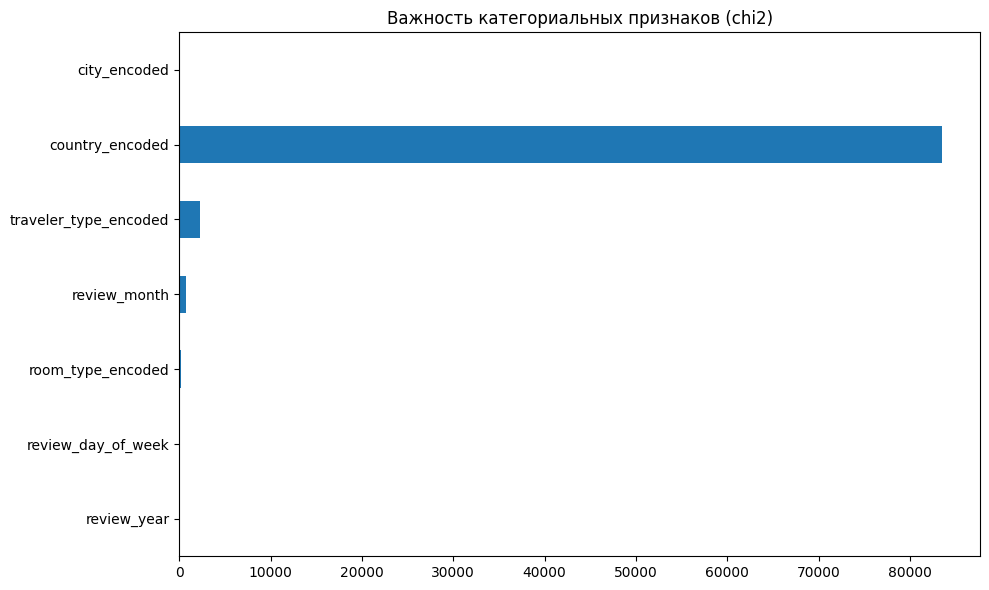

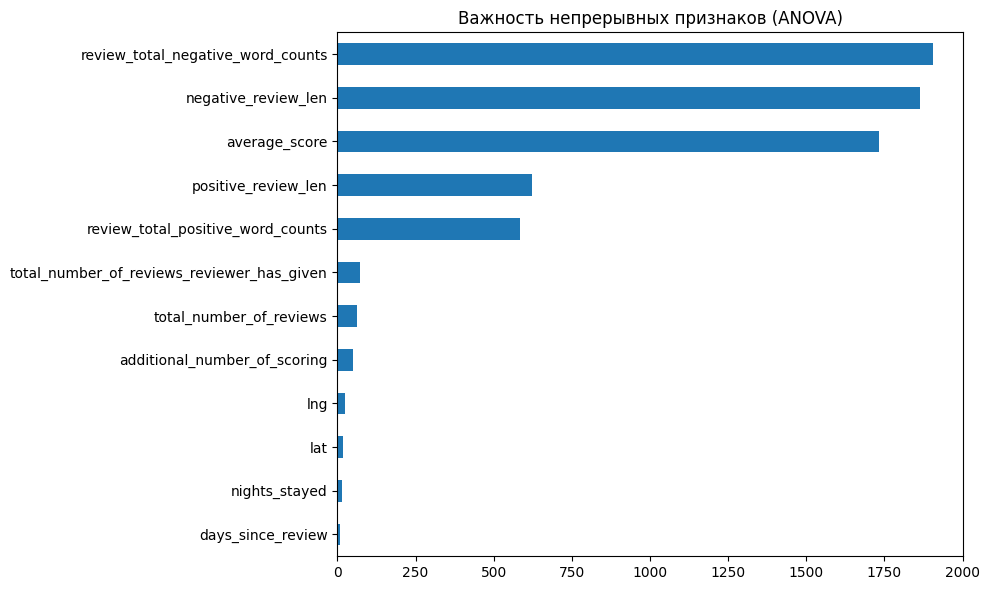

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
# Категориальные признаки (для chi2)
cat_cols = [
    'country_encoded', 'city_encoded', 'traveler_type_encoded',
    'room_type_encoded', 'review_month', 'review_year', 'review_day_of_week'
]

# Непрерывные признаки (для f_classif)
num_cols_for_test = [
    'average_score', 'review_total_negative_word_counts',
    'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given',
    'total_number_of_reviews', 'days_since_review', 'additional_number_of_scoring',
    'lat', 'lng', 'nights_stayed', 'negative_review_len', 'positive_review_len'
]

# Для chi2 нужно преобразовать y в int и убедиться, что признаки неотрицательные
y_int = y.astype(int)

# Проверяем значимость категориальных признаков
try:
    from sklearn.feature_selection import chi2
    imp_cat = pd.Series(chi2(X_scaled[cat_cols].clip(lower=0), y_int)[0], index=cat_cols)
    imp_cat.sort_values(inplace=True)
    
    plt.figure(figsize=(10, 6))
    imp_cat.plot(kind='barh')
    plt.title('Важность категориальных признаков (chi2)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Ошибка при расчете chi2: {e}")

# Оценка значимости непрерывных признаков
try:
    from sklearn.feature_selection import f_classif
    imp_num = pd.Series(f_classif(X_scaled[num_cols_for_test], y)[0], index=num_cols_for_test)
    imp_num.sort_values(inplace=True)
    
    plt.figure(figsize=(10, 6))
    imp_num.plot(kind='barh')
    plt.title('Важность непрерывных признаков (ANOVA)')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Ошибка при расчете ANOVA: {e}")


# ОТБОР ПРИЗНАКОВ

c:\Users\egork\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [16] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\egork\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



Выбрано 10 лучших признаков:
['average_score', 'review_total_negative_word_counts', 'review_total_positive_word_counts', 'total_number_of_reviews_reviewer_has_given', 'total_number_of_reviews', 'additional_number_of_scoring', 'lng', 'negative_review_len', 'positive_review_len', 'traveler_type_encoded']


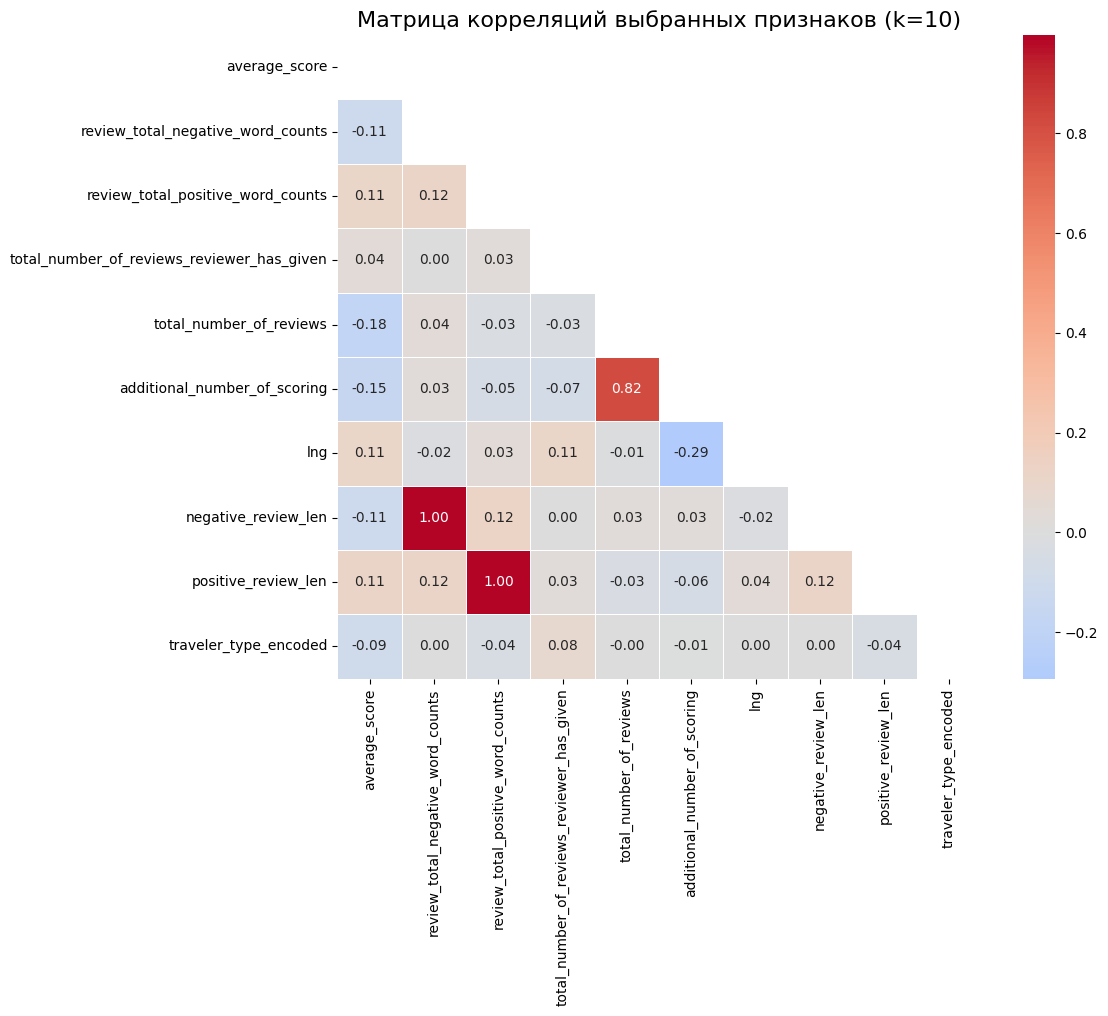

In [18]:
from sklearn.feature_selection import SelectKBest
k_best = 10
selector = SelectKBest(score_func=f_classif, k=k_best)
X_selected = selector.fit_transform(X_scaled, y)

# Получаем индексы выбранных признаков
selected_indices = selector.get_support(indices=True)
selected_features = X_scaled.columns[selected_indices]

print(f"\nВыбрано {k_best} лучших признаков:")
print(selected_features.tolist()) 

plt.figure(figsize=(12, 10))
X_selected_df = pd.DataFrame(X_selected, columns=selected_features)
corr_matrix_selected = X_selected_df.corr()
mask = np.triu(np.ones_like(corr_matrix_selected, dtype=bool))
sns.heatmap(corr_matrix_selected, mask=mask, annot=True, cmap='coolwarm', 
            center=0, linewidths=0.5, fmt='.2f', square=True,
            annot_kws={'size': 10})
plt.title(f'Матрица корреляций выбранных признаков (k={len(selected_features)})', fontsize=16)
plt.tight_layout()
plt.show()

In [17]:
# Все категориальные признаки
cat_cols = [
    'country_encoded', 
    'city_encoded', 
    'traveler_type_encoded',
    'room_type_encoded', 
    'review_month', 
    'review_year', 
    'review_day_of_week'
]

# Все непрерывные признаки
num_cols_for_test = [
    'average_score', 
    'review_total_negative_word_counts',
    'review_total_positive_word_counts', 
    'total_number_of_reviews_reviewer_has_given',
    'total_number_of_reviews', 
    'days_since_review', 
    'additional_number_of_scoring',
    'lat', 
    'lng', 
    'nights_stayed', 
    'negative_review_len', 
    'positive_review_len'
]


In [18]:
# Уникальные отели по названию
unique_hotels = hotels['hotel_name'].nunique()
print(f"Количество уникальных отелей: {unique_hotels}")

Количество уникальных отелей: 1492


In [19]:
# Преобразуем дату
hotels['review_date'] = pd.to_datetime(hotels['review_date'])

latest_review = hotels['review_date'].max()
earliest_review = hotels['review_date'].min()

print(f"Самый свежий отзыв: {latest_review.strftime('%Y-%m-%d')}")
print(f"Самый первый отзыв: {earliest_review.strftime('%Y-%m-%d')}")

Самый свежий отзыв: 2017-08-03
Самый первый отзыв: 2015-08-04


In [31]:
import re
all_tags = []

for tags in hotels['tags'].dropna():
    tags_str = str(tags)
    
    # Удаляем лишние символы: [ ] { } " '
    tags_str = re.sub(r'[\[\]{}"\']', '', tags_str)
    
    # Разделяем по запятой
    tag_list = [tag.strip() for tag in tags_str.split(',')]
    
    # Убираем пустые теги
    tag_list = [tag for tag in tag_list if tag and tag != '']
    all_tags.extend(tag_list)

unique_tags = set(all_tags)

print(f"Количество уникальных тегов: {len(unique_tags)}")

Количество уникальных тегов: 2368


In [21]:
from collections import Counter

# Считаем частоту каждого тега
tag_counter = Counter(all_tags)
most_common_tag = tag_counter.most_common(1)[0]

print(f"Самый частый тег: '{most_common_tag[0]}' - {most_common_tag[1]} отзывов")

Самый частый тег: '[' Leisure trip '' - 312768 отзывов


In [22]:
# Используем созданный ранее признак nights_stayed
most_common_nights = hotels['nights_stayed'].mode()[0]
print(f"Чаще всего останавливаются на {most_common_nights} ночей")

Чаще всего останавливаются на 1 ночей


In [24]:
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели  
from sklearn import metrics # инструменты для оценки точности модели  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
# Создаём модель  
regr = RandomForestRegressor(n_estimators=100)  
      
# Обучаем модель на тестовом наборе данных  
regr.fit(X_train, y_train)  
      
# Используем обученную модель для предсказания рейтинга отелей в тестовой выборке.  
# Предсказанные значения записываем в переменную y_pred  
y_pred = regr.predict(X_test)  

In [25]:
# Сравниваем предсказанные значения (y_pred) с реальными (y_test), и смотрим насколько они отличаются  
# Метрика называется Mean Absolute Percentage Error (MAPE) и показывает среднюю абсолютную процентную ошибку предсказанных значений от фактических.  
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))

MAPE: 0.13193007116391617


Небольшой бонус:


In [10]:
# # убираем признаки которые еще не успели обработать, 
# # модель на признаках с dtypes "object" обучаться не будет, просто выберим их и удалим
# object_columns = [s for s in hotels.columns if hotels[s].dtypes == 'object']
# hotels.drop(object_columns, axis = 1, inplace=True)

# # заполняем пропуски самым простым способом
# hotels = hotels.fillna(0)